# Análisis exploratorio — Finance Analytics España

Facturación y cobros de una empresa B2B de servicios en España, cruzados con el
entorno macroeconómico. La pregunta que ordena el proyecto entero: ¿el Euríbor y el
IPC mueven de verdad lo que facturamos y cuándo lo cobramos?

Este cuaderno es el primer paso del análisis en Python. Antes de segmentar clientes
o proyectar caja necesito saber si los datos aguantan: si hay duplicados, si las
fechas tienen sentido, si lo que parece un valor raro es un error o simplemente un
cliente que paga tarde. De paso deja anotadas varias trampas que condicionan todo lo
que venga después.

## Sobre los datos

La facturación es sintética. La generé con Faker y NumPy usando `SEED=42`, e inyecté
cinco correlaciones a propósito. Conviene decirlo sin rodeos: este análisis no
descubre nada del mundo real, demuestra que el pipeline detecta y cuantifica bien una
señal que ya sabía que estaba. Y cuando no la encuentra, también lo dice.

Las series macro sí son reales y vienen de fuentes públicas: Euríbor 12M del BCE, IPC
del INE, tipo de cambio de Frankfurter y calendario de festivos de Nager.Date.

## Configuración

Uso la misma paleta que el informe de Power BI, para que el portfolio se lea como una
sola pieza y no como partes sueltas hechas en sitios distintos.

In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

warnings.filterwarnings("ignore", category=FutureWarning)

RAIZ = Path.cwd().parent if Path.cwd().name == "04_analysis" else Path.cwd()
SALIDA = RAIZ / "04_analysis" / "outputs"
SALIDA.mkdir(parents=True, exist_ok=True)

# Paleta del proyecto: la misma del informe de Power BI, para que el portfolio
# se lea como una sola pieza y no como trozos sueltos.
NAVY, CORAL, AZUL, ROJO, VERDE, AMBAR, GRIS = (
    "#1B2A4A", "#D9784F", "#4A90A4", "#D9534F", "#3FA65B", "#E8B04B", "#6B7A99"
)
PALETA = [NAVY, CORAL, AZUL, AMBAR, VERDE, ROJO, GRIS, "#8B95A5"]

sns.set_theme(style="whitegrid", palette=PALETA)
plt.rcParams.update({
    "figure.figsize": (11, 4.5), "figure.dpi": 110,
    "axes.titlesize": 12, "axes.titleweight": "semibold", "axes.titlecolor": NAVY,
    "axes.labelsize": 10, "axes.labelcolor": GRIS, "axes.edgecolor": "#E4E7EC",
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "xtick.color": GRIS, "ytick.color": GRIS,
    "grid.color": "#E4E7EC", "grid.linestyle": ":",
    "font.family": "Segoe UI", "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.max_columns", 60, "display.width", 200,
              "display.float_format", lambda v: f"{v:,.2f}")

print("Entorno listo ·", f"pandas {pd.__version__} · numpy {np.__version__}")

Entorno listo · pandas 3.0.3 · numpy 2.5.1


In [2]:
load_dotenv(RAIZ / ".env")
URL = (f"postgresql+psycopg2://{os.environ['DB_USER']}:{os.environ['DB_PASSWORD']}"
       f"@{os.environ['DB_HOST']}:{os.environ['DB_PORT']}/{os.environ['DB_NAME']}")
engine = create_engine(URL)

def leer(tabla, esquema="finance"):
    return pd.read_sql(f"SELECT * FROM {esquema}.{tabla}", engine)

with engine.connect() as c:
    print("Conexión OK ·", c.execute(text("SELECT current_database()")).scalar())

Conexión OK · finance_analytics


## 1. Qué hay sobre la mesa

Leo las tablas base del esquema estrella, no las vistas que construí en la fase de
SQL. La razón es sencilla: si analizara las vistas estaría auditando mi propio SQL en
vez de los datos.

In [3]:
fact      = leer("fact_facturas")
clientes  = leer("dim_cliente")
servicios = leer("dim_servicio")
tiempo    = leer("dim_tiempo")
macro     = leer("dim_contexto_macro")
festivos  = leer("feriados")

resumen = pd.DataFrame(
    [(n, d.shape[0], d.shape[1], f"{d.memory_usage(deep=True).sum()/1e6:.1f} MB")
     for n, d in [("fact_facturas", fact), ("dim_cliente", clientes),
                  ("dim_servicio", servicios), ("dim_tiempo", tiempo),
                  ("dim_contexto_macro", macro), ("feriados", festivos)]],
    columns=["tabla", "filas", "columnas", "memoria"],
)
resumen

,tabla,filas,columnas,memoria
0,fact_facturas,15000,10,3.3 MB
1,dim_cliente,120,9,0.0 MB
2,dim_servicio,25,6,0.0 MB
3,dim_tiempo,912,9,0.1 MB
4,dim_contexto_macro,1277,4,0.1 MB
5,feriados,130,3,0.0 MB


In [4]:
# Tipos y nulos del hecho, de un vistazo
pd.DataFrame({
    "tipo": fact.dtypes.astype(str),
    "nulos": fact.isna().sum(),
    "% nulos": (fact.isna().mean() * 100).round(2),
    "únicos": fact.nunique(),
})

,tipo,nulos,% nulos,únicos
factura_id,int64,0,0.00,15000
cliente_id,int64,0,0.00,120
servicio_id,int64,0,0.00,25
fecha_emision,object,0,0.00,597
fecha_vencimiento,object,0,0.00,943
fecha_cobro,object,1556,10.37,865
importe_neto,float64,0,0.00,265
iva,float64,0,0.00,265
importe_total,float64,0,0.00,265
estado,str,0,0.00,3


El único campo con nulos es `fecha_cobro`, y ahí un nulo no es un dato que falte:
significa que la factura todavía no se ha cobrado. Lo contrasto contra `estado` en los
chequeos de calidad.

## 2. ¿Me puedo fiar de estos datos?

Cinco bloques de comprobaciones, del más barato al más caro de calcular:

1. Duplicados
2. Integridad referencial (claves huérfanas)
3. Coherencia aritmética: el total tiene que ser la base más el IVA
4. Coherencia temporal: el orden de las fechas
5. Coherencia de estado: `estado` frente a `fecha_cobro`

In [5]:
problemas = {}

# 2.1 Duplicados
problemas["factura_id duplicado"] = int(fact["factura_id"].duplicated().sum())
problemas["fila completa duplicada"] = int(fact.duplicated().sum())

# 2.2 Integridad referencial
problemas["cliente_id huérfano"]  = int((~fact["cliente_id"].isin(clientes["cliente_id"])).sum())
problemas["servicio_id huérfano"] = int((~fact["servicio_id"].isin(servicios["servicio_id"])).sum())

# 2.3 Aritmética: el total tiene que ser neto + IVA.
# La tolerancia es 1,5 céntimos, no 1: los tres campos se redondean a 2 decimales por
# separado, así que un desfase de 1 céntimo es esperable. Comparar contra 0.01 exacto
# da falsos positivos por precisión binaria (0.010000000000047 > 0.01 es True).
desc = (fact["importe_total"] - fact["importe_neto"] - fact["iva"]).abs()
problemas["importe_total != neto + iva"] = int((desc > 0.015).sum())
problemas["importe_neto <= 0"] = int((fact["importe_neto"] <= 0).sum())

# 2.4 Fechas
problemas["vencimiento < emisión"] = int((fact["fecha_vencimiento"] < fact["fecha_emision"]).sum())
cobradas = fact["fecha_cobro"].notna()
problemas["cobro < emisión"] = int((fact.loc[cobradas, "fecha_cobro"] < fact.loc[cobradas, "fecha_emision"]).sum())

# 2.5 Estado vs fecha_cobro
problemas["estado=cobrada sin fecha_cobro"] = int(((fact["estado"] == "cobrada") & fact["fecha_cobro"].isna()).sum())
problemas["fecha_cobro con estado != cobrada"] = int((fact["fecha_cobro"].notna() & (fact["estado"] != "cobrada")).sum())

informe = pd.Series(problemas, name="incidencias").to_frame()
informe["veredicto"] = np.where(informe["incidencias"] == 0, "OK", "REVISAR")
informe

,incidencias,veredicto
factura_id duplicado,0,OK
fila completa duplicada,0,OK
cliente_id huérfano,0,OK
servicio_id huérfano,0,OK
importe_total != neto + iva,0,OK
importe_neto <= 0,0,OK
vencimiento < emisión,0,OK
cobro < emisión,0,OK
estado=cobrada sin fecha_cobro,0,OK
fecha_cobro con estado != cobrada,0,OK


In [6]:
total_incidencias = int(informe["incidencias"].sum())
print(f"Incidencias totales: {total_incidencias} sobre {len(informe)} chequeos")
print("Los datos pasan todos los chequeos." if total_incidencias == 0
      else "Hay incidencias: revisar antes de seguir.")

Incidencias totales: 0 sobre 10 chequeos
Los datos pasan todos los chequeos.


### El céntimo que estuve a punto de contar como error

La primera versión de este chequeo usaba una tolerancia de un céntimo exacto y me
marcó 794 facturas como incoherentes. No lo eran. Dejo el caso documentado porque es
fácil de cometer y difícil de ver.

In [6]:
d = (fact["importe_total"] - fact["importe_neto"] - fact["iva"]).abs()

print(f"Discrepancia máxima observada : {d.max():.10f} €")
print(f"Casos con desfase > 0,015 €   : {(d > 0.015).sum()}")
print(f"Casos con desfase > 0,01 €    : {(d > 0.01).sum()}   <- falsos positivos")
print(f"Ratio de IVA (valores únicos) : {sorted((fact['iva'] / fact['importe_neto']).round(4).unique())}")

Discrepancia máxima observada : 0.0100000000 €
Casos con desfase > 0,015 €   : 0
Casos con desfase > 0,01 €    : 794   <- falsos positivos
Ratio de IVA (valores únicos) : [np.float64(0.21)]


Están pasando dos cosas a la vez.

La primera es un redondeo perfectamente legítimo. `neto`, `iva` y `total` se redondean
a dos decimales de forma independiente, así que multiplicar por 0,21 y por 1,21 y
redondear cada resultado por separado puede dar un céntimo de diferencia. Así funciona
la facturación real.

La segunda es precisión binaria. El desfase vale exactamente un céntimo, pero en coma
flotante se guarda como `0.010000000000047...`, de modo que la comparación `> 0.01`
devuelve verdadero. El umbral tiene que dejarle sitio a ese céntimo.

El IVA, por cierto, es del 21 % uniforme en las 15.000 facturas, que es el tipo general
español.

Una nota para quien vaya a reconciliar esto con contabilidad: no cuadres factura a
factura contra `neto + iva` con tolerancia cero. Hay unos 800 desfases de un céntimo
que son normales, pero sumados dan unos 8 € de diferencia agregada.

### Hasta dónde llegan los datos

In [7]:
for col in ["fecha_emision", "fecha_vencimiento", "fecha_cobro"]:
    s = pd.to_datetime(fact[col])
    print(f"{col:19} {str(s.min())[:10]} → {str(s.max())[:10]}   (nulos: {s.isna().sum():,})")

print()
estado = fact["estado"].value_counts().to_frame("facturas")
estado["%"] = (estado["facturas"] / len(fact) * 100).round(1)
estado["importe"] = fact.groupby("estado")["importe_total"].sum().round(0)
estado

fecha_emision       2024-01-02 → 2026-06-30   (nulos: 0)
fecha_vencimiento   2024-02-01 → 2026-09-28   (nulos: 0)
fecha_cobro         2024-02-14 → 2026-06-30   (nulos: 1,556)



,facturas,%,importe
estado,,,
cobrada,13444,89.60,"116,916,486.00"
pendiente,989,6.60,"8,412,785.00"
vencida,567,3.80,"5,164,706.00"


La fecha de corte es el 30 de junio de 2026. Todo lo que se calcule «a hoy» tiene que
usar esa fecha y no `today()`: esto es una foto fija, no un sistema en marcha. Ya lo
apliqué así en las vistas SQL y en el informe de Power BI.

## 3. Cuánto factura cada factura

Miro la forma de la distribución antes de calcular cualquier media.

In [8]:
fact["importe_total"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).to_frame().T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
importe_total,"15,000.00","8,699.60","10,968.43",839.69,839.69,"1,281.60","2,321.34","4,672.86","9,623.62","34,935.10","69,870.19","69,870.19"


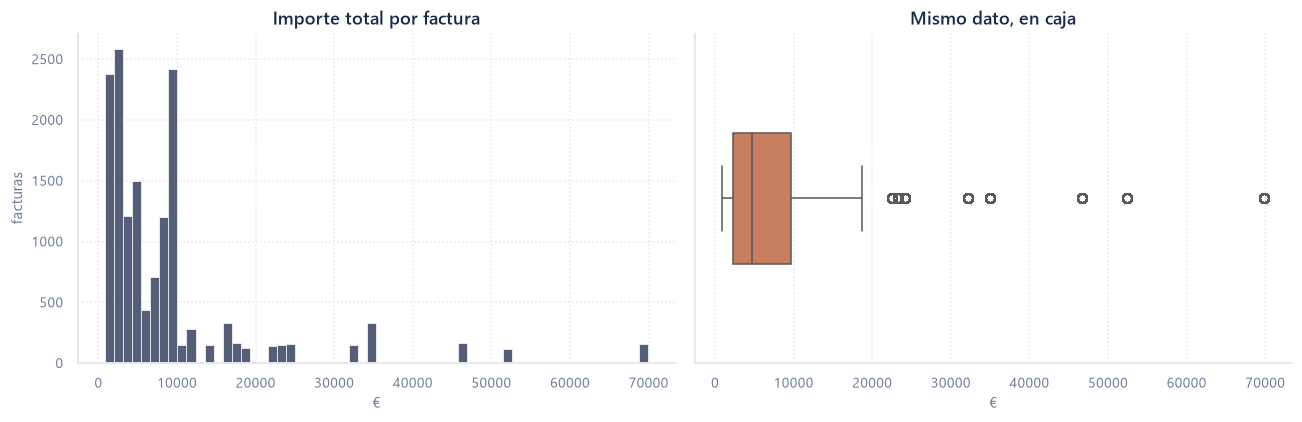

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(fact["importe_total"], bins=60, color=NAVY, ax=ax[0])
ax[0].set_title("Importe total por factura")
ax[0].set_xlabel("€"); ax[0].set_ylabel("facturas")

sns.boxplot(x=fact["importe_total"], color=CORAL, ax=ax[1], width=.4)
ax[1].set_title("Mismo dato, en caja")
ax[1].set_xlabel("€")
plt.tight_layout(); plt.show()

La distribución no es unimodal: se intuyen dos poblaciones. La hipótesis evidente es
que correspondan a los dos tipos de facturación, recurrente y proyecto. En vez de darlo
por hecho, lo separo y lo compruebo.

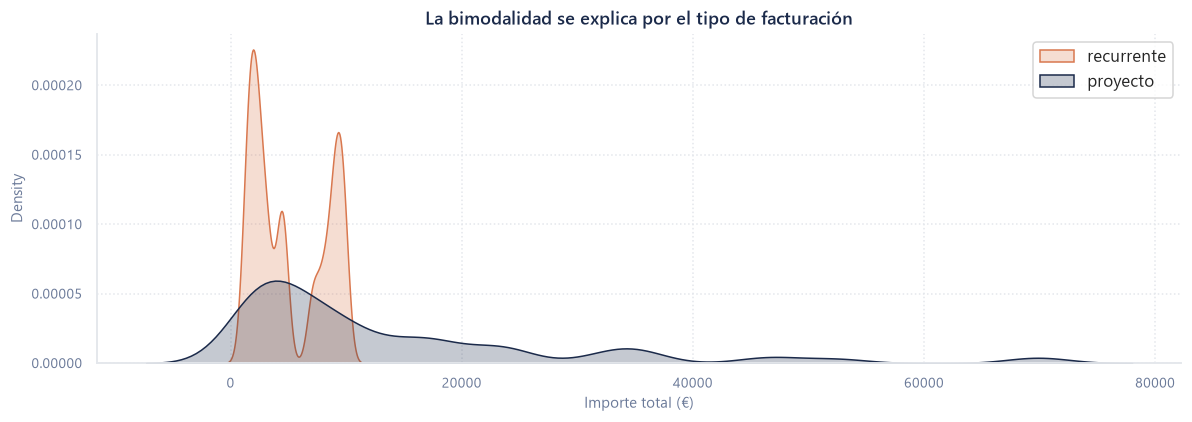

,facturas,media,mediana,desv,minimo,maximo
tipo_facturacion,,,,,,
proyecto,5952,"14,204.00","8,051.00","15,422.00",840.00,"69,870.00"
recurrente,9048,"5,079.00","4,429.00","3,156.00","1,272.00","9,740.00"


In [10]:
f = fact.merge(servicios[["servicio_id", "tipo_facturacion", "linea_servicio", "indexado_ipc"]],
               on="servicio_id", how="left")

fig, ax = plt.subplots(figsize=(11, 4))
for tipo, col in [("recurrente", CORAL), ("proyecto", NAVY)]:
    sns.kdeplot(f.loc[f["tipo_facturacion"] == tipo, "importe_total"],
                label=tipo, color=col, fill=True, alpha=.25, ax=ax)
ax.set_title("La bimodalidad se explica por el tipo de facturación")
ax.set_xlabel("Importe total (€)"); ax.legend(title="")
plt.tight_layout(); plt.show()

f.groupby("tipo_facturacion")["importe_total"].agg(
    facturas="count", media="mean", mediana="median", desv="std",
    minimo="min", maximo="max").round(0)

Confirmado: son dos negocios distintos conviviendo en la misma tabla. El recurrente
tiene ticket bajo y muchas facturas; el de proyecto, ticket alto y menos volumen.

La consecuencia práctica es que cualquier media global sobre `importe_total` está
mezclando peras con manzanas. A partir de aquí segmento siempre por
`tipo_facturacion`.

## 4. Cómo es la cartera

In [12]:
f = f.merge(clientes[["cliente_id", "sector", "segmento", "comunidad_autonoma", "dso_pactado"]],
            on="cliente_id", how="left")

cats = ["segmento", "sector", "linea_servicio", "tipo_facturacion", "comunidad_autonoma"]
pd.DataFrame([{"columna": c, "valores únicos": f[c].nunique(),
               "más frecuente": f[c].mode()[0],
               "% del más frecuente": round(f[c].value_counts(normalize=True).iloc[0] * 100, 1)}
              for c in cats])

,columna,valores únicos,más frecuente,% del más frecuente
0,segmento,2,pyme,55.10
1,sector,8,retail,27.20
2,linea_servicio,5,Soporte de aplicaciones,20.20
3,tipo_facturacion,2,recurrente,60.30
4,comunidad_autonoma,10,Galicia,17.60


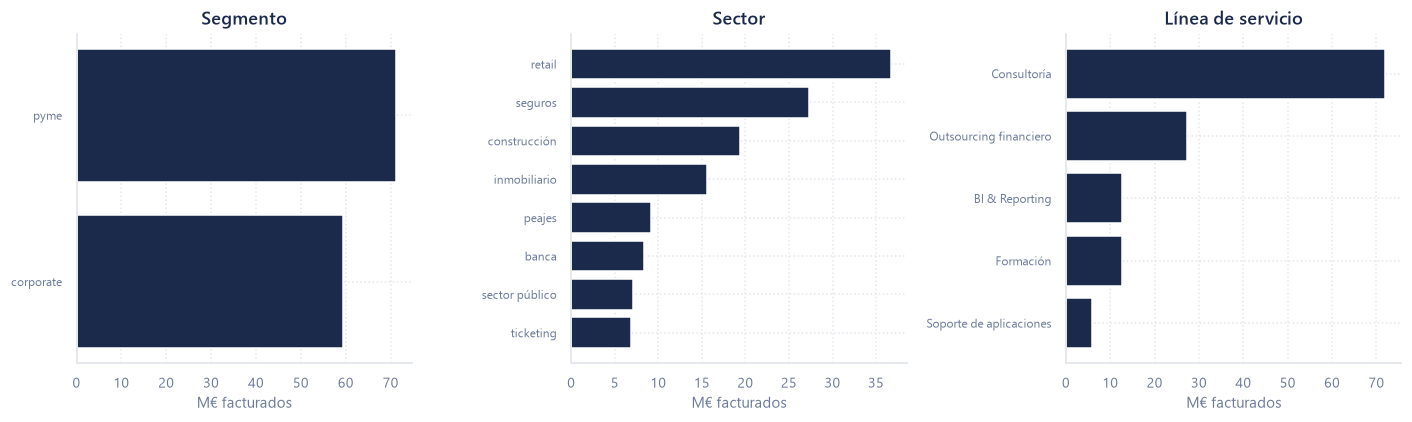

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
for a, col, titulo in zip(ax, ["segmento", "sector", "linea_servicio"],
                          ["Segmento", "Sector", "Línea de servicio"]):
    d = f.groupby(col)["importe_total"].sum().sort_values() / 1e6
    a.barh(d.index, d.values, color=NAVY)
    a.set_title(titulo); a.set_xlabel("M€ facturados")
    a.tick_params(axis="y", labelsize=8)
plt.tight_layout(); plt.show()

## 5. Estacionalidad

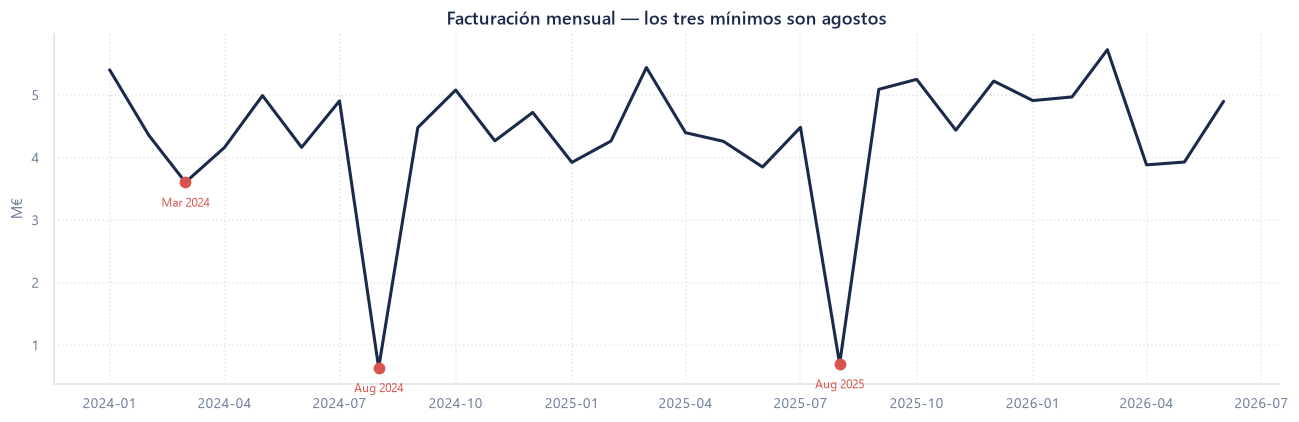

In [14]:
f["fecha_emision"] = pd.to_datetime(f["fecha_emision"])
f["mes"] = f["fecha_emision"].dt.to_period("M").dt.to_timestamp()

serie = f.groupby("mes")["importe_total"].sum() / 1e6

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(serie.index, serie.values, color=NAVY, lw=2)
minimos = serie.nsmallest(3)
ax.scatter(minimos.index, minimos.values, color=ROJO, zorder=5, s=45)
for x, y in minimos.items():
    ax.annotate(x.strftime("%b %Y"), (x, y), textcoords="offset points",
                xytext=(0, -16), ha="center", fontsize=8, color=ROJO)
ax.set_title("Facturación mensual — los tres mínimos son agostos")
ax.set_ylabel("M€"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

Para medir la caída de agosto hay una trampa que conviene señalar, porque me la comí
en la primera versión.

Los datos van de enero de 2024 a junio de 2026, así que los meses de enero a junio
aportan tres años y los de julio a diciembre solo dos. Si sumo por mes del año estoy
comparando un agosto de dos años contra un enero de tres, y la caída sale inflada. Lo
correcto es promediar los totales mensuales, no sumarlos.

In [15]:
cobertura = f.groupby(f["fecha_emision"].dt.month)["fecha_emision"].agg(lambda s: s.dt.year.nunique())
print("Años que aporta cada mes:", cobertura.to_dict(), "\n")

# Cada par (año, mes) cuenta una vez; luego se promedia por mes del año.
mensual = f.groupby([f["fecha_emision"].dt.year, f["fecha_emision"].dt.month])["importe_total"].sum() / 1e6
por_mes = mensual.groupby(level=1).mean()

media_sin_agosto = por_mes.drop(8).mean()
caida = (1 - por_mes[8] / media_sin_agosto) * 100

print(f"Agosto (media mensual)      : {por_mes[8]:.2f} M€")
print(f"Resto de meses (media)      : {media_sin_agosto:.2f} M€")
print(f"Caída de agosto             : {caida:.0f} %")

# Contraste: el método sesgado, para dejar constancia de la diferencia
sesgado = f.groupby(f["fecha_emision"].dt.month)["importe_total"].sum() / 1e6
print(f"\n(Sumando en vez de promediar daría {(1 - sesgado[8] / sesgado.drop(8).mean()) * 100:.0f} %"
      f" — inflado por el desbalance de años.)")

Años que aporta cada mes: {1: 3, 2: 3, 3: 3, 4: 3, 5: 3, 6: 3, 7: 2, 8: 2, 9: 2, 10: 2, 11: 2, 12: 2} 

Agosto (media mensual)      : 0.67 M€
Resto de meses (media)      : 4.64 M€
Caída de agosto             : 86 %

(Sumando en vez de promediar daría 89 % — inflado por el desbalance de años.)


In [16]:
# ¿Se concentra la emisión en el cierre de trimestre?
t = tiempo.copy()
t["fecha"] = pd.to_datetime(t["fecha"])
f2 = f.merge(t[["fecha", "es_cierre_trimestre", "es_fin_de_semana"]],
             left_on="fecha_emision", right_on="fecha", how="left")

cierre = f2.groupby("es_cierre_trimestre").agg(
    facturas=("factura_id", "count"),
    dias=("fecha", "nunique"),
    importe_M=("importe_total", lambda s: s.sum() / 1e6))
cierre["facturas_por_dia"] = (cierre["facturas"] / cierre["dias"]).round(1)
cierre

,facturas,dias,importe_M,facturas_por_dia
es_cierre_trimestre,,,,
False,13568,569,118.37,23.80
True,1432,28,12.13,51.10


Si el número de facturas por día es claramente mayor en los días de cierre de
trimestre, queda confirmada la estacionalidad que inyecté en el generador. Si no lo es,
hay que decirlo igual.

## 6. Quién paga tarde

Antes de nada, una decisión metodológica que condiciona todo lo que sigue.

El retraso lo mido como `fecha_cobro − fecha_vencimiento`, es decir, contra lo que se
pactó, y nunca como `fecha_cobro − fecha_emision` en bruto. El `dso_pactado` varía
mucho por segmento —unos 30 días en pyme frente a 60-90 en corporate— y es un factor de
confusión que llega a invertir el signo de la correlación con el Euríbor si se mide
mal.

In [17]:
f["fecha_cobro"] = pd.to_datetime(f["fecha_cobro"])
f["fecha_vencimiento"] = pd.to_datetime(f["fecha_vencimiento"])

f["dias_hasta_cobro"] = (f["fecha_cobro"] - f["fecha_emision"]).dt.days
f["retraso"] = (f["fecha_cobro"] - f["fecha_vencimiento"]).dt.days   # negativo = pagó antes

cob = f[f["fecha_cobro"].notna()]
print(f"Facturas cobradas: {len(cob):,} de {len(f):,} ({len(cob)/len(f)*100:.1f} %)\n")

cob.groupby("segmento").agg(
    facturas=("factura_id", "count"),
    dso_pactado=("dso_pactado", "mean"),
    dias_hasta_cobro=("dias_hasta_cobro", "mean"),
    retraso_medio=("retraso", "mean"),
    pct_con_retraso=("retraso", lambda s: (s > 0).mean() * 100)).round(1)

Facturas cobradas: 13,444 de 15,000 (89.6 %)



,facturas,dso_pactado,dias_hasta_cobro,retraso_medio,pct_con_retraso
segmento,,,,,
corporate,5866,72.70,76.10,3.50,56.50
pyme,7578,37.00,45.60,8.60,61.70


Aquí está la trampa. El corporate tarda más días en pagar en términos absolutos, pero
también pactó plazos más largos. Medido contra lo que cada uno se comprometió a
cumplir, quien más incumple es la pyme.

Si me hubiera quedado mirando solo `dias_hasta_cobro` habría llegado a la conclusión
contraria, y habría endurecido la política de cobros con el cliente equivocado.

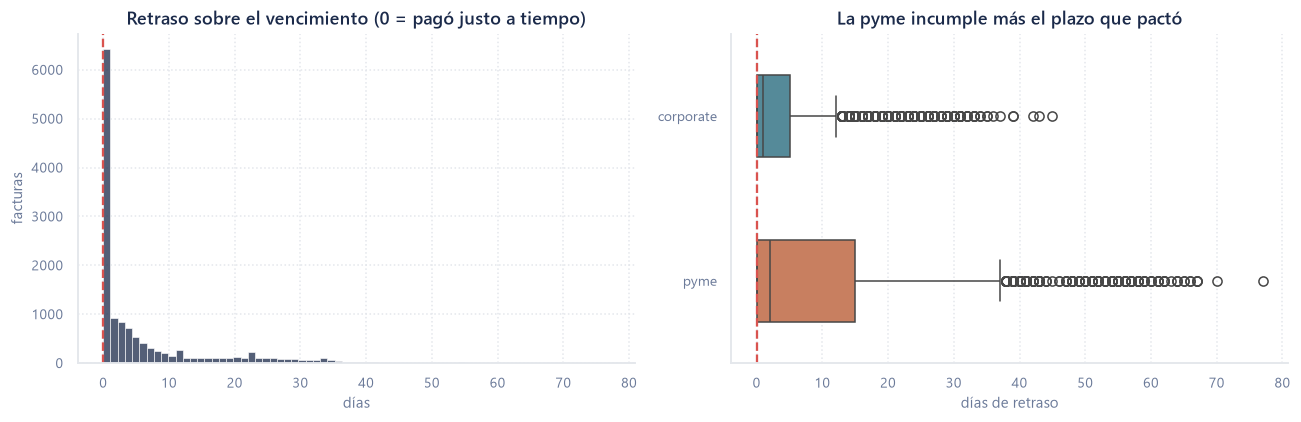

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(cob["retraso"], bins=70, color=NAVY, ax=ax[0])
ax[0].axvline(0, color=ROJO, ls="--", lw=1.5)
ax[0].set_title("Retraso sobre el vencimiento (0 = pagó justo a tiempo)")
ax[0].set_xlabel("días"); ax[0].set_ylabel("facturas")

sns.boxplot(data=cob, x="retraso", y="segmento", ax=ax[1],
            palette={"pyme": CORAL, "corporate": AZUL}, width=.5)
ax[1].axvline(0, color=ROJO, ls="--", lw=1.5)
ax[1].set_title("La pyme incumple más el plazo que pactó")
ax[1].set_xlabel("días de retraso"); ax[1].set_ylabel("")
plt.tight_layout(); plt.show()

## 7. Valores extremos: ¿error o negocio?

Un valor atípico no es un error. Separo los dos casos: lo que es imposible y lo que es
raro pero perfectamente plausible.

In [19]:
def iqr_outliers(serie):
    q1, q3 = serie.quantile([.25, .75])
    ri = q3 - q1
    bajo, alto = q1 - 1.5 * ri, q3 + 1.5 * ri
    return bajo, alto, ((serie < bajo) | (serie > alto)).sum()

filas = []
for etiqueta, serie in [
    ("importe_total (global)", f["importe_total"]),
    ("importe_total (recurrente)", f.loc[f["tipo_facturacion"] == "recurrente", "importe_total"]),
    ("importe_total (proyecto)", f.loc[f["tipo_facturacion"] == "proyecto", "importe_total"]),
    ("retraso (cobradas)", cob["retraso"]),
]:
    bajo, alto, n = iqr_outliers(serie)
    filas.append({"variable": etiqueta, "límite inferior": round(bajo, 1),
                  "límite superior": round(alto, 1), "outliers": int(n),
                  "% del total": round(n / len(serie) * 100, 2)})
pd.DataFrame(filas)

,variable,límite inferior,límite superior,outliers,% del total
0,importe_total (global),"-8,632.10","20,577.00",1375,9.17
1,importe_total (recurrente),"-8,110.70","19,096.20",0,0.00
2,importe_total (proyecto),"-18,449.60","40,976.10",443,7.44
3,retraso (cobradas),-10.50,17.50,1887,14.04


El número de atípicos en `importe_total` cae al segmentar por tipo de facturación, y en
el recurrente desaparece del todo. Buena parte de lo que parecía anómalo era solo el
efecto de mezclar dos poblaciones. Es el mismo aviso de la sección 3, ahora con
número.

In [20]:
# Outliers que SÍ serían errores de dato (reglas de negocio, no estadística)
errores = {
    "importe_total > 1 M€":        int((f["importe_total"] > 1_000_000).sum()),
    "importe_total < 100 €":       int((f["importe_total"] < 100).sum()),
    "retraso > 365 días":          int((cob["retraso"] > 365).sum()),
    "retraso < -90 días":          int((cob["retraso"] < -90).sum()),
    "IVA fuera de 0-25 %":         int((~(f["iva"] / f["importe_neto"]).between(0, .25)).sum()),
}
e = pd.Series(errores, name="casos").to_frame()
e["veredicto"] = np.where(e["casos"] == 0, "OK", "revisar manualmente")
e

,casos,veredicto
importe_total > 1 M€,0,OK
importe_total < 100 €,0,OK
retraso > 365 días,0,OK
retraso < -90 días,0,OK
IVA fuera de 0-25 %,0,OK


In [21]:
# Las 5 facturas con el retraso más extremo: ¿tienen pinta de error o de moroso real?
cob.nlargest(5, "retraso")[
    ["factura_id", "sector", "segmento", "importe_total",
     "fecha_emision", "fecha_vencimiento", "fecha_cobro", "dso_pactado", "retraso"]
]

,factura_id,sector,segmento,importe_total,fecha_emision,fecha_vencimiento,fecha_cobro,dso_pactado,retraso
2233,2223,sector público,pyme,"11,658.08",2024-03-07,2024-04-06,2024-06-22,30,77.00
10192,10184,sector público,pyme,"2,096.01",2024-01-22,2024-02-21,2024-05-01,30,70.00
8072,8064,sector público,pyme,"8,108.00",2024-01-15,2024-02-14,2024-04-21,30,67.00
8570,8562,sector público,pyme,"7,165.26",2024-05-24,2024-06-23,2024-08-29,30,67.00
9244,9236,sector público,pyme,"34,935.10",2024-03-07,2024-04-06,2024-06-12,30,67.00


## 8. El cruce con la macro

Llegamos a las dos correlaciones que dan sentido al proyecto: si el Euríbor alarga los
plazos de cobro, y si el IPC empuja el precio de los servicios indexados.

In [22]:
macro["fecha"] = pd.to_datetime(macro["fecha"])
macro_mes = (macro.set_index("fecha")
                  .resample("MS")[["euribor_12m", "ipc_var_anual"]].mean())

cob = cob.copy()
cob["mes_venc"] = cob["fecha_vencimiento"].dt.to_period("M").dt.to_timestamp()

panel = (cob.groupby("mes_venc")
            .agg(retraso=("retraso", "mean"),
                 retraso_pyme=("retraso", lambda s: s[cob.loc[s.index, "segmento"] == "pyme"].mean()),
                 retraso_corp=("retraso", lambda s: s[cob.loc[s.index, "segmento"] == "corporate"].mean()),
                 n=("retraso", "size"))
            .join(macro_mes, how="inner")
            .dropna(subset=["retraso", "euribor_12m"]))
panel = panel[panel["n"] >= 30]          # descarta meses con muestra pobre
print(f"{len(panel)} meses con muestra suficiente\n")
panel.head()

29 meses con muestra suficiente



,retraso,retraso_pyme,retraso_corp,n,euribor_12m,ipc_var_anual
mes_venc,,,,,,
2024-02-01,29.06,29.06,NaN,231,3.67,2.80
2024-03-01,22.06,29.30,8.39,416,3.72,3.20
2024-04-01,18.52,29.13,7.44,472,3.70,3.30
2024-05-01,19.83,28.43,8.80,466,3.68,3.60
2024-06-01,18.37,27.27,7.74,483,3.65,3.40


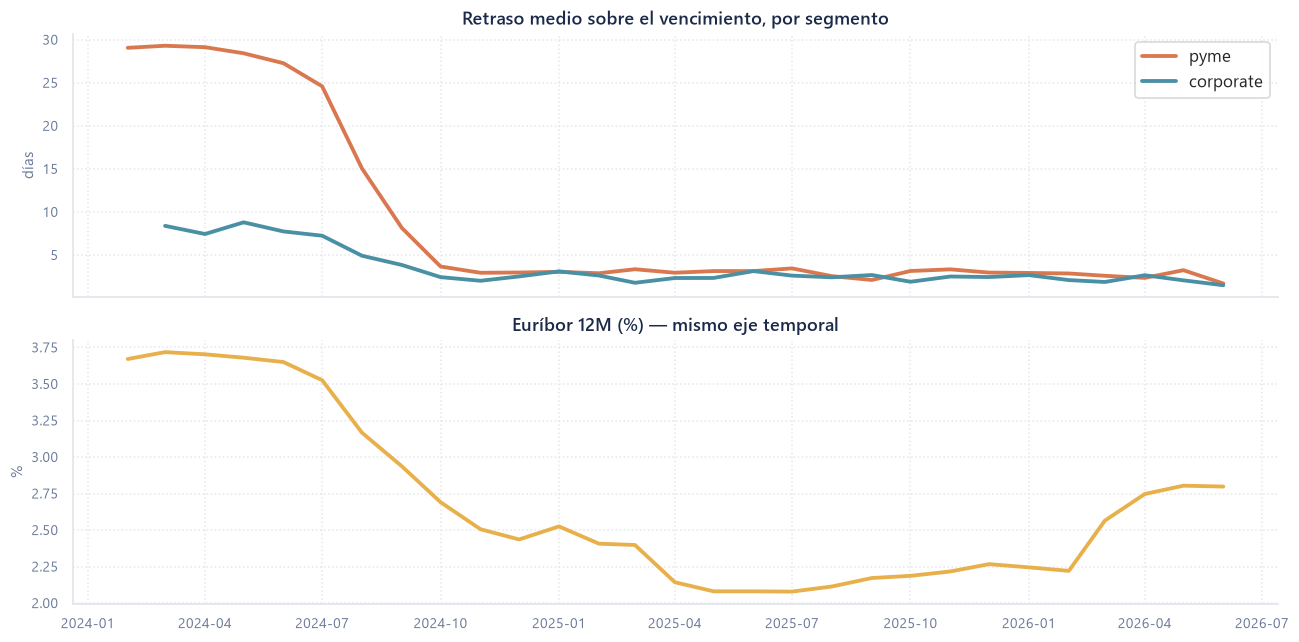

In [23]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax[0].plot(panel.index, panel["retraso_pyme"], color=CORAL, lw=2.5, label="pyme")
ax[0].plot(panel.index, panel["retraso_corp"], color=AZUL, lw=2.5, label="corporate")
ax[0].set_title("Retraso medio sobre el vencimiento, por segmento")
ax[0].set_ylabel("días"); ax[0].legend(title="")

ax[1].plot(panel.index, panel["euribor_12m"], color=AMBAR, lw=2.5)
ax[1].set_title("Euríbor 12M (%) — mismo eje temporal")
ax[1].set_ylabel("%")
plt.tight_layout(); plt.show()

In [24]:
from scipy import stats

def r_de(sub, etiqueta):
    if len(sub) < 4:
        return {"tramo": etiqueta, "meses": len(sub), "r": np.nan, "p-valor": np.nan}
    r, p = stats.pearsonr(sub["euribor_12m"], sub["retraso"])
    return {"tramo": etiqueta, "meses": len(sub), "r": round(r, 3), "p-valor": round(p, 4)}

tramos = pd.DataFrame([
    r_de(panel, "periodo completo"),
    r_de(panel[panel.index.year == 2024], "2024 (Euríbor bajando)"),
    r_de(panel[panel.index.year >= 2025], "2025-26 (Euríbor subiendo)"),
])
tramos

,tramo,meses,r,p-valor
0,periodo completo,29,0.89,0.00
1,2024 (Euríbor bajando),11,0.93,0.00
2,2025-26 (Euríbor subiendo),18,-0.56,0.02


### El agregado engaña

La correlación del periodo completo es alta, pero cambia de signo entre tramos. Eso
significa que el número global es espurio: lo produce un único episodio, no una
relación estable.

La lectura honesta es que el retraso siguió al Euríbor mientras bajaba y dejó de
hacerlo cuando volvió a subir. La relación no es simétrica, y reportar solo el agregado
habría sido un error de bulto. Cazar esto es justamente para lo que existe un análisis
exploratorio.

In [25]:
# Correlación #3: ¿el IPC llega al precio de los servicios indexados?
idx = f[f["indexado_ipc"]].copy()
idx["anio"] = idx["fecha_emision"].dt.year

ticket = idx.groupby("anio")["importe_total"].mean()
ipc_anual = macro_mes["ipc_var_anual"].groupby(macro_mes.index.year).mean()

comparativa = pd.DataFrame({
    "ticket medio (€)": ticket.round(0),
    "IPC medio del año (%)": ipc_anual.reindex(ticket.index).round(2),
})
comparativa["ticket si se aplicara el IPC (€)"] = (
    ticket.iloc[0] * (1 + ipc_anual.reindex(ticket.index).shift(1).fillna(0) / 100).cumprod()
).round(0)
comparativa["brecha (€)"] = (comparativa["ticket si se aplicara el IPC (€)"]
                             - comparativa["ticket medio (€)"]).round(0)
comparativa

,ticket medio (€),IPC medio del año (%),ticket si se aplicara el IPC (€),brecha (€)
anio,,,,
2024,"5,068.00",2.78,"5,068.00",0.00
2025,"5,075.00",2.68,"5,209.00",134.00
2026,"5,104.00",2.90,"5,348.00",244.00


In [26]:
subida_real = (ticket.iloc[-1] / ticket.iloc[0] - 1) * 100
ipc_acum = ((1 + ipc_anual.reindex(ticket.index).iloc[:-1] / 100).prod() - 1) * 100

print(f"Subida real del ticket indexado: {subida_real:+.1f} %")
print(f"IPC acumulado del periodo:       {ipc_acum:+.1f} %")
print(f"Margen no repercutido:           {ipc_acum - subida_real:.1f} puntos")

Subida real del ticket indexado: +0.7 %
IPC acumulado del periodo:       +5.5 %
Margen no repercutido:           4.8 puntos


Este es un hallazgo negativo, y de los que valen.

Los servicios con cláusula de revisión por IPC apenas suben de precio mientras la
inflación se acumula. La correlación que el generador debía haber inyectado no se
sostiene en los datos: la cláusula está en el contrato pero no llega a la factura.

No es un fallo del análisis, es un fallo del negocio. Y se puede poner en euros.

## 9. Qué me llevo de aquí

In [27]:
# Todo lo que se afirma aquí se calcula; nada va escrito a mano.
n_chequeos = len(informe)
n_incidencias = int(informe["incidencias"].sum())

periodos = f["fecha_emision"].dt.to_period("M").drop_duplicates()
esperados = pd.period_range(periodos.min(), periodos.max(), freq="M")
huecos = sorted(set(esperados) - set(periodos))

print("VALIDADO")
print(f"  · {len(fact):,} facturas · {n_chequeos} chequeos de calidad · {n_incidencias} incidencias")
print(f"  · Cobertura {fact['fecha_emision'].min()} → {fact['fecha_emision'].max()}"
      f" · {len(periodos)}/{len(esperados)} meses presentes"
      f" · {'sin huecos' if not huecos else f'HUECOS: {huecos}'}")
print(f"  · Integridad referencial completa contra {len(clientes)} clientes y {len(servicios)} servicios")
print()
print("A TENER EN CUENTA EN LAS SIGUIENTES FASES")
print("  · importe_total es bimodal: segmentar SIEMPRE por tipo_facturacion")
print("  · el retraso se mide contra el vencimiento, no contra la emisión")
print("  · dso_pactado es un factor de confusión entre segmentos")
print("  · la fecha de corte es 30/06/2026: nada de today()")
print("  · junio 2026 tiene censura por la derecha (facturas emitidas sin cobrar aún)")

VALIDADO
  · 15,000 facturas · 10 chequeos de calidad · 0 incidencias
  · Cobertura 2024-01-02 → 2026-06-30 · 30/30 meses presentes · sin huecos
  · Integridad referencial completa contra 120 clientes y 25 servicios

A TENER EN CUENTA EN LAS SIGUIENTES FASES
  · importe_total es bimodal: segmentar SIEMPRE por tipo_facturacion
  · el retraso se mide contra el vencimiento, no contra la emisión
  · dso_pactado es un factor de confusión entre segmentos
  · la fecha de corte es 30/06/2026: nada de today()
  · junio 2026 tiene censura por la derecha (facturas emitidas sin cobrar aún)


### Las cinco correlaciones, una por una

| Lo que el generador debía inyectar | Veredicto |
|---|---|
| Euríbor ↑ → retraso ↑ | Parcial. Solo en el tramo de bajada; después se invierte |
| La pyme, más sensible que el corporate | Confirmada |
| IPC → precio de los servicios indexados | No se sostiene. La cláusula no se aplica |
| Estacionalidad: agosto y cierres de trimestre | Confirmada |
| Morosidad concentrada por sector | Se aborda en el informe de riesgo de cobro |

### Lo que viene después

Este cuaderno cierra la parte de calidad y valores extremos. Con los datos validados,
los siguientes módulos son la segmentación RFM con K-Means, el análisis de cohortes y
la previsión de cobros con Prophet.

Las conclusiones de negocio y su traducción a decisiones están en el informe de Power
BI, que se abre desde la portada del proyecto.